## HateXplain - 3 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np

from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [8]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
task_config = {
    "General": {"type": "hate_speech"},
    "Women": {"type": "group_hate", "group": "Women"},
    "Homosexual": {"type": "group_hate", "group": "Homosexual"},
    #"Indigenous": {"type": "group_hate", "group": "Indigenous"},
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [02:36<00:00,  3.08it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [10]:
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

15:09:18 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:09:18 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:03<00:00, 63.02it/s] 


Epoch 1 - Average loss: 0.7346


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 81.04it/s]


Epoch 2 - Average loss: 0.7190


Epoch 3/3: 100%|██████████| 241/241 [00:03<00:00, 70.03it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:03<00:00, 78.47it/s]


Epoch 2 - Average loss: 0.3777


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 82.08it/s]


Epoch 3 - Average loss: 0.3801


15:43:34 | DEBUG | machinemoo | New solution added [0.58910109 0.3499457  0.26536741]
15:43:34 | DEBUG | machinemoo | Solution dominated [0.58922133 0.35001468 0.26553334]
15:43:34 | DEBUG | machinemoo | Solution dominated [0.58942733 0.35047168 0.26546206]
15:43:34 | DEBUG | machinemoo | Solution dominated [0.58938014 0.3505236  0.26546254]
15:43:34 | DEBUG | machinemoo | Solution dominated [0.58922062 0.35000264 0.26564901]
15:43:34 | DEBUG | machinemoo | Calculated weights: [1.88725198e-01 5.73738508e-07 8.11274223e-01]
15:43:34 | DEBUG | machinemoo | Importance: 4.329079491477428e-05
15:43:34 | DEBUG | machinemoo | Global lower bound (y*): [0.58874964 0.34972801 0.26523948]
15:43:34 | DEBUG | machinemoo | Iteration 150
15:43:34 | DEBUG | machinemoo | Solutions list: [array([0.58910109, 0.3499457 , 0.26536741]), array([0.58945837, 0.35029069, 0.26532393]), array([0.58965102, 0.3500108 , 0.26523948]), array([0.58881621, 0.35087461, 0.26612667]), array([0.58874964, 0.35032857, 0.26637

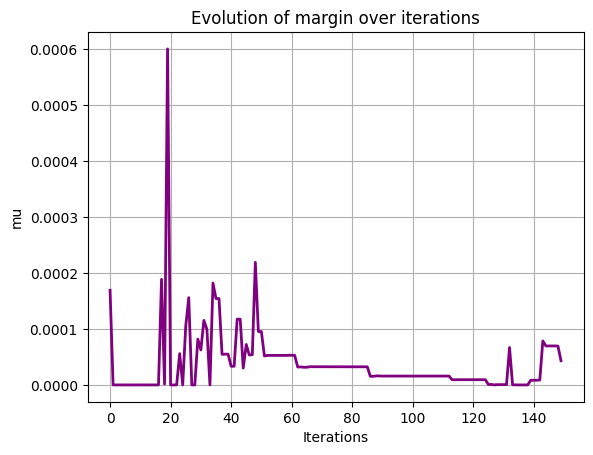

15:43:34 | INFO | machinemoo | Fit runtime: 2056.17 seconds


In [11]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

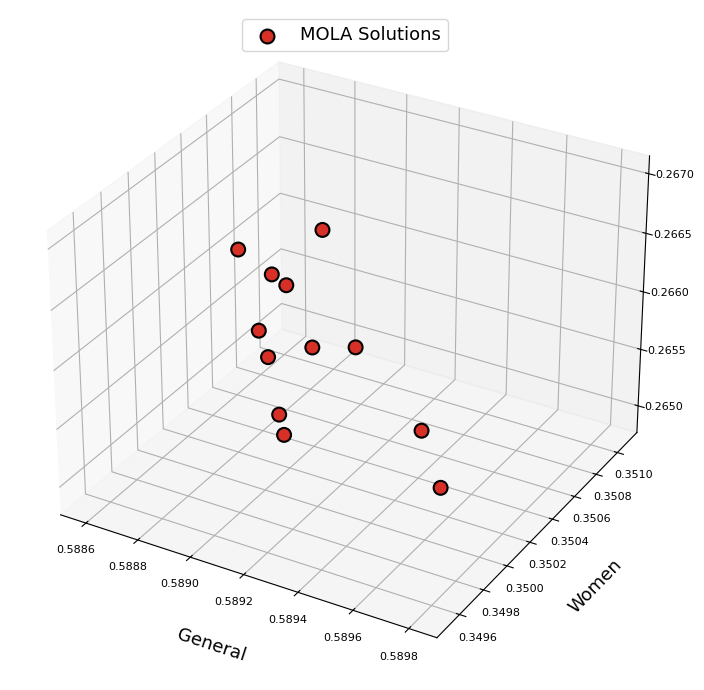

In [12]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola': results['mola']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=13,
            figsize=(10,7),
            save_path='images/3_objs_mola.pdf'
            )

15:43:35 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
15:43:35 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:03<00:00, 61.35it/s]


Epoch 1 - Average loss: 0.6799


Epoch 2/3: 100%|██████████| 241/241 [00:04<00:00, 55.95it/s]


Epoch 2 - Average loss: 0.6694


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 81.09it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 87.12it/s]


Epoch 2 - Average loss: 0.6099


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 95.47it/s]


Epoch 3 - Average loss: 0.6090


16:12:39 | DEBUG | machinemoo | New solution dominated [0.58917824 0.39090831 0.29247525]
16:12:39 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [0.37385828 0.23651378 0.18027206]
16:12:39 | DEBUG | machinemoo | Calculated weights: [1. 0. 0.]
16:12:39 | DEBUG | machinemoo | Importance: 0.21487984896506374
16:12:39 | DEBUG | machinemoo | Global lower bound (y*): [0.37385828 0.23651378 0.18027206]
16:12:39 | DEBUG | machinemoo | Iteration 150
16:12:39 | DEBUG | machinemoo | Solutions list: [array([0.58873814, 0.3909392 , 0.29238454]), array([0.58895095, 0.38968899, 0.29105817]), array([0.58885501, 0.38982317, 0.29087779]), array([0.58924789, 0.38820106, 0.29004596]), array([0.58937037, 0.38791457, 0.28951767]), array([0.58915732, 0.38825812, 0.29001853]), array([0.58952257, 0.38858101, 0.28930753]), array([0.58897735, 0.38858509, 0.28917402]), array([0.58925639, 0.38827291, 0.2893238 ]), array([0.58934324, 0.38806227, 0.28931838]), array([0.59000307, 0.38783855, 0.288977

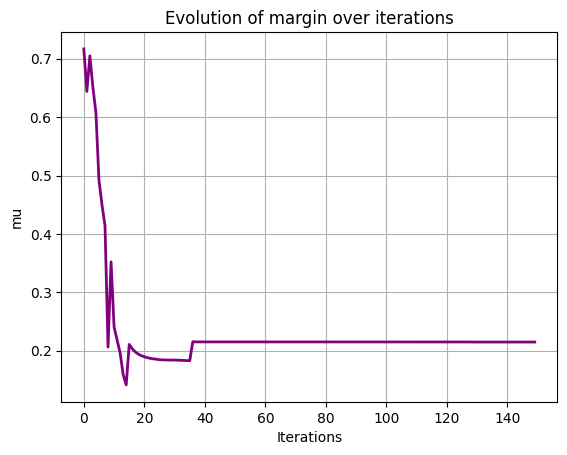

16:12:39 | INFO | machinemoo | Fit runtime: 1743.95 seconds


In [13]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names,
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

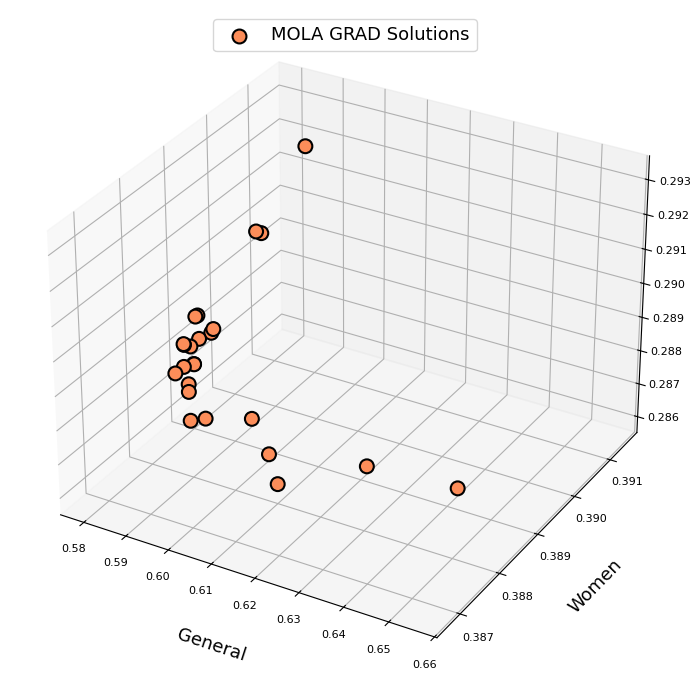

In [14]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola_grad': results['mola_grad']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=13,
            figsize=(10,7),
            color=['#fc8d59'],
            save_path='images/3_objs_mola_grad.pdf'
            )

### Random Weights

In [15]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

16:12:39 | WARNING | machinemoo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
16:12:39 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
16:12:39 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/3:   0%|          | 0/241 [00:00<?, ?it/s]

Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 92.81it/s] 


Epoch 1 - Average loss: 0.7239


Epoch 2/3: 100%|██████████| 241/241 [00:03<00:00, 76.07it/s]


Epoch 2 - Average loss: 0.7118


...

Epoch 2/3: 100%|██████████| 241/241 [00:03<00:00, 76.28it/s]


Epoch 2 - Average loss: 0.4370


Epoch 3/3: 100%|██████████| 241/241 [00:03<00:00, 64.98it/s]


Epoch 3 - Average loss: 0.4365


16:42:56 | DEBUG | machinemoo | 150th solution


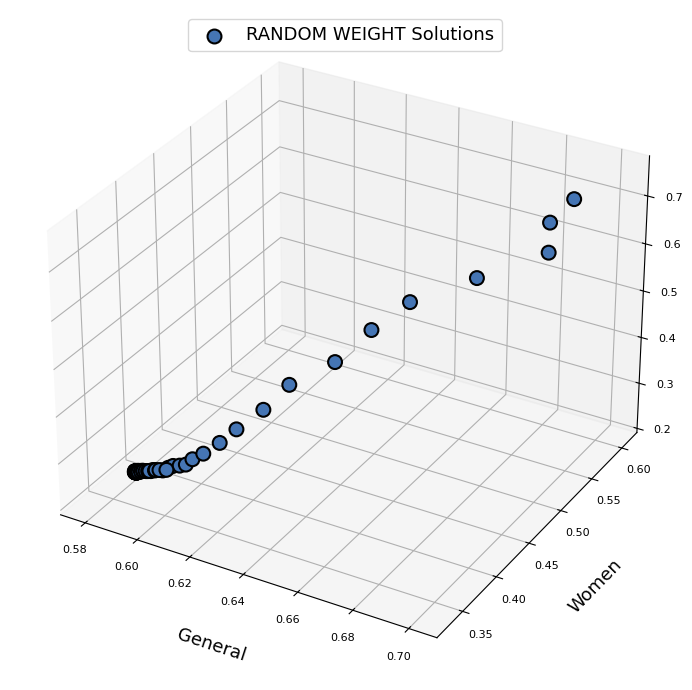

In [16]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'random_weight': results['random_weight']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=13,
            figsize=(10,7),
            color=['#4575b4'],
            save_path='images/3_objs_rw.pdf'
            )

In [17]:
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]

print(f"Número de soluções não-dominadas: {len(non_dominated_solutions)}")
print(non_dominated_solutions)


Número de soluções não-dominadas: 11
[[0.58887388 0.35048023 0.26548322]
 [0.58911671 0.35025038 0.26517111]
 [0.58906613 0.34984777 0.26521919]
 [0.58890996 0.34974983 0.26542029]
 [0.58892973 0.35023538 0.26521412]
 [0.5886426  0.35072943 0.26569618]
 [0.58908315 0.35024449 0.26520989]
 [0.58917032 0.34970787 0.26544789]
 [0.58905556 0.34968483 0.26553451]
 [0.58911938 0.34962945 0.26599029]
 [0.58908554 0.35074492 0.26508575]]


In [18]:
# Supondo que `solutions` seja seu array (N x M)
solutions = results['mola']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]

print(f"Número de soluções não-dominadas: {len(non_dominated_solutions)}")
print(non_dominated_solutions)

Número de soluções não-dominadas: 12
[[0.58910109 0.3499457  0.26536741]
 [0.58945837 0.35029069 0.26532393]
 [0.58965102 0.3500108  0.26523948]
 [0.58881621 0.35087461 0.26612667]
 [0.58874964 0.35032857 0.26637773]
 [0.5888243  0.35032868 0.26572815]
 [0.5890681  0.35060486 0.26549451]
 [0.58899874 0.35003992 0.26587669]
 [0.589128   0.34991967 0.2666688 ]
 [0.58918824 0.34972801 0.26580754]
 [0.58905095 0.34996962 0.26666572]
 [0.58900391 0.35038359 0.26565104]]


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

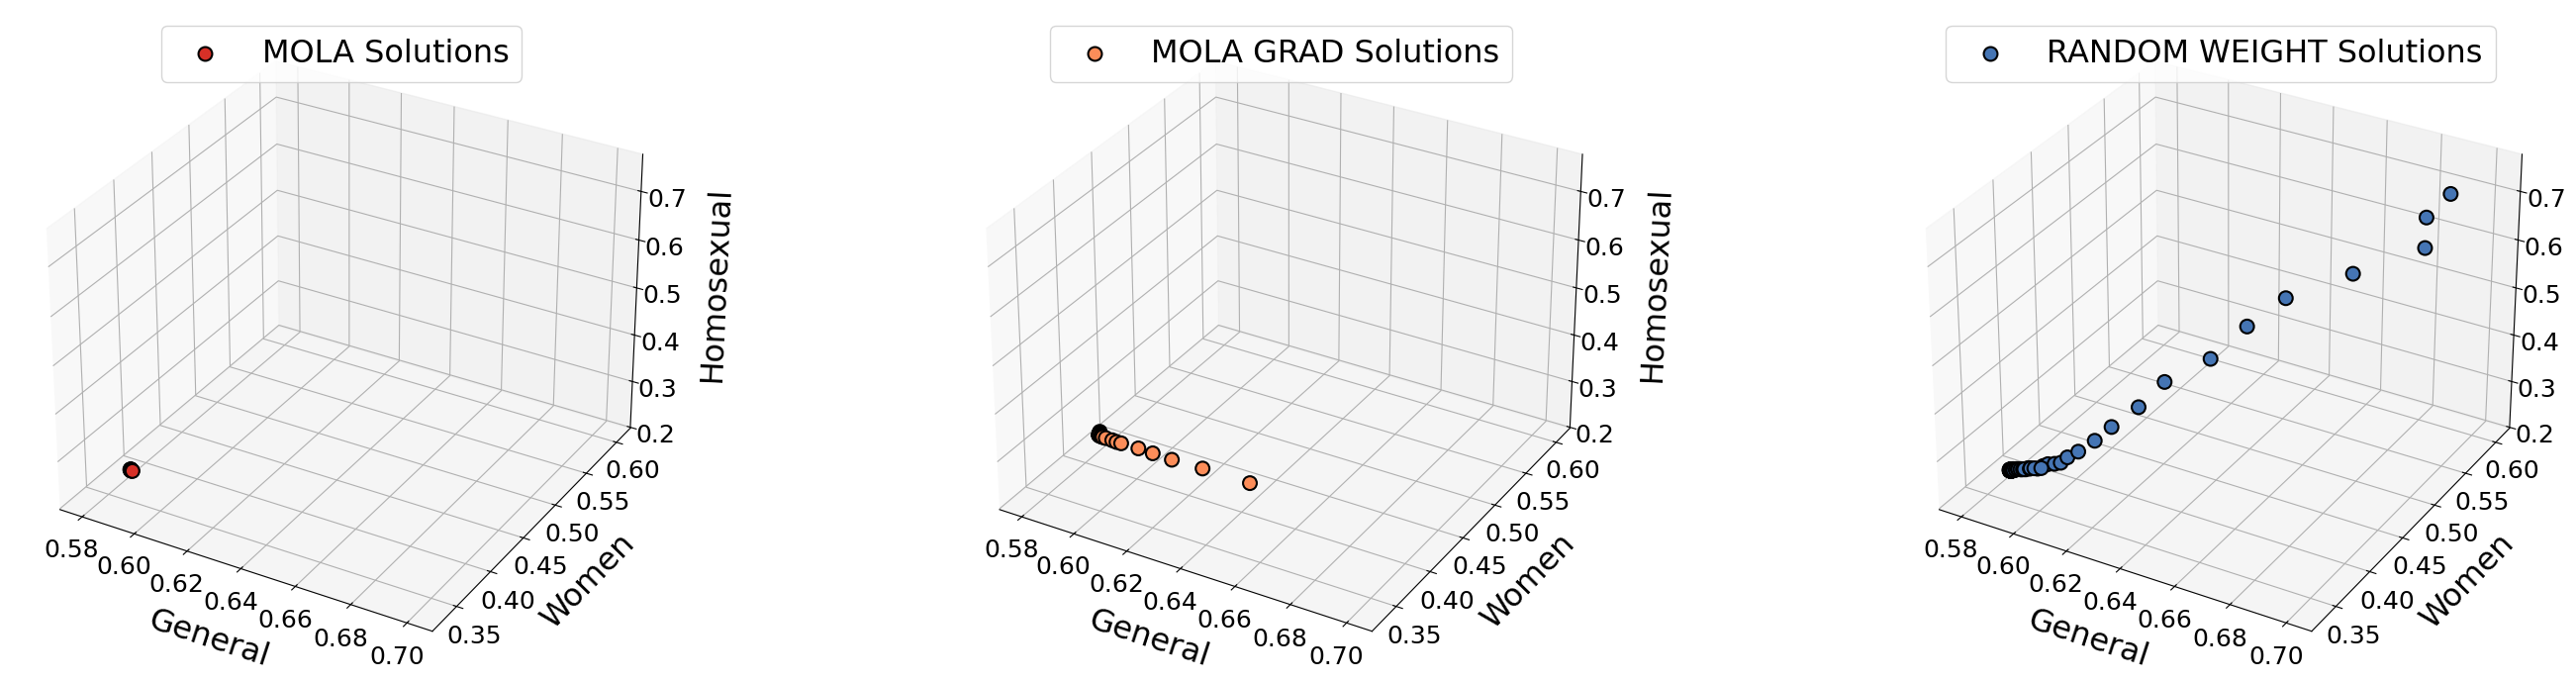

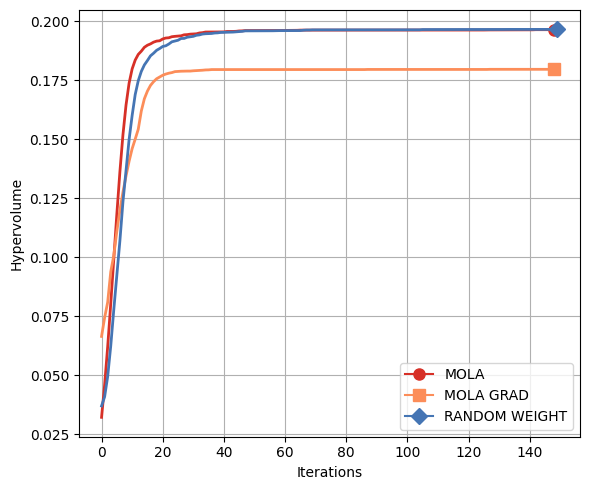

<Figure size 640x480 with 0 Axes>

In [22]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/3_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path="images/3_objs_hypervolume.pdf")

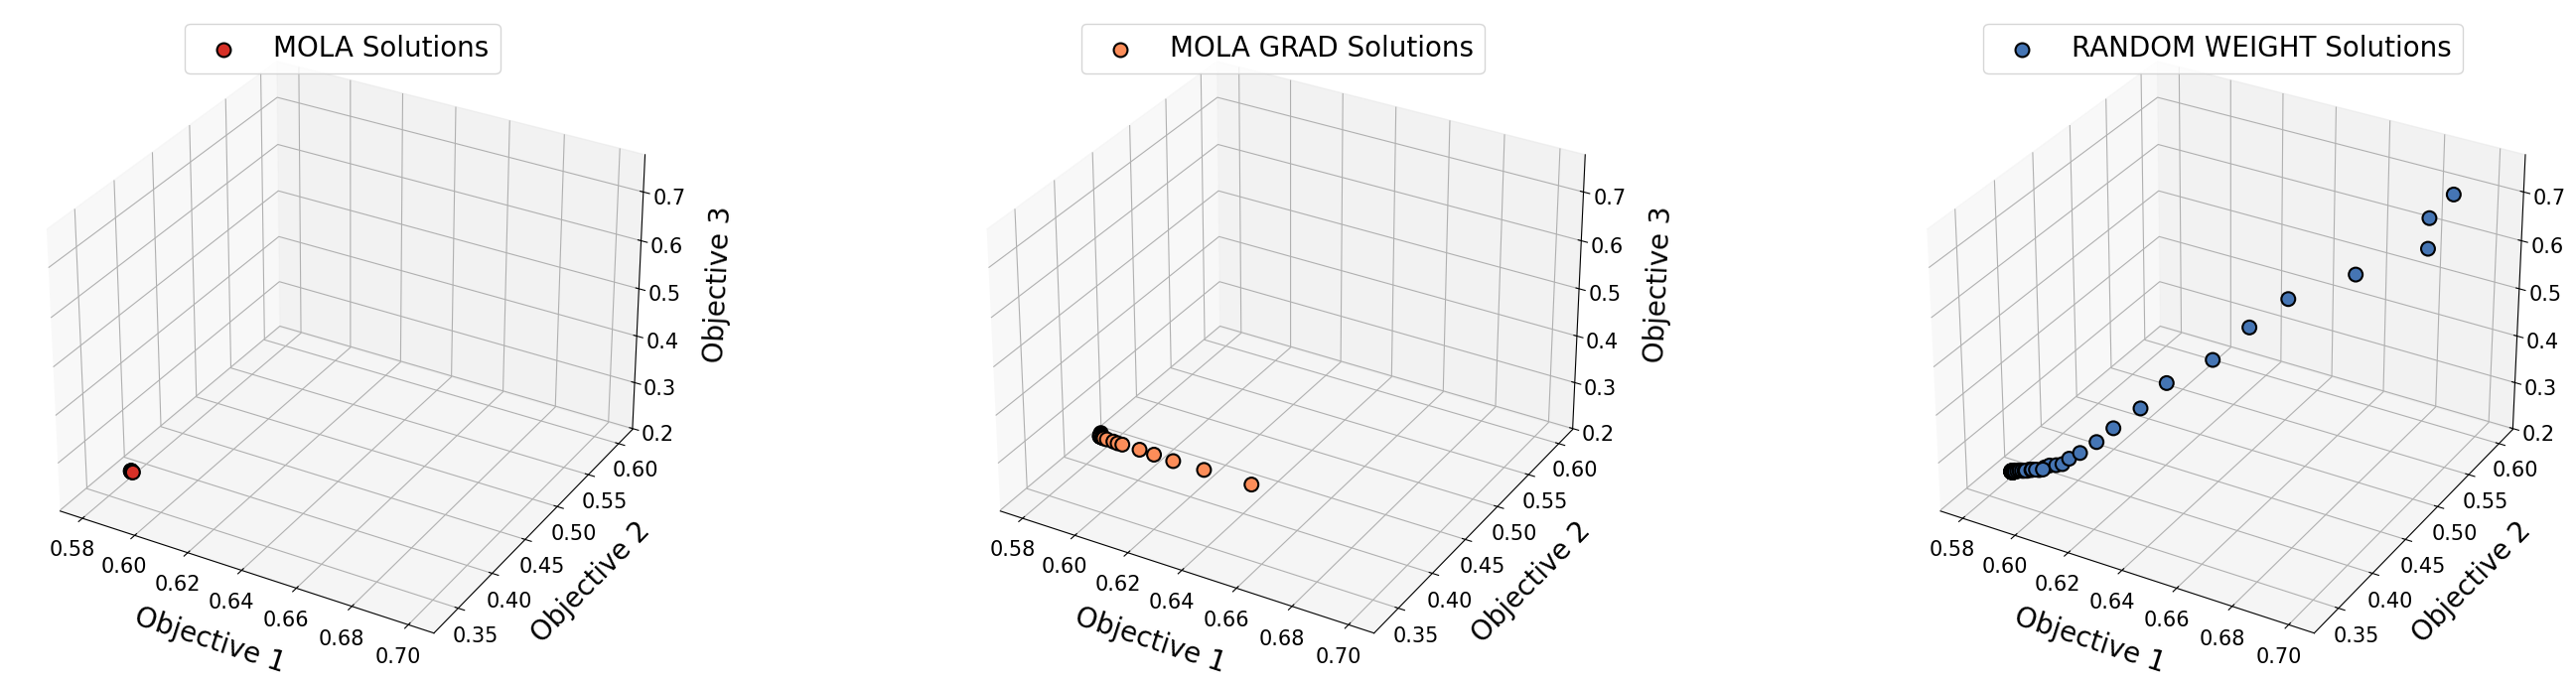

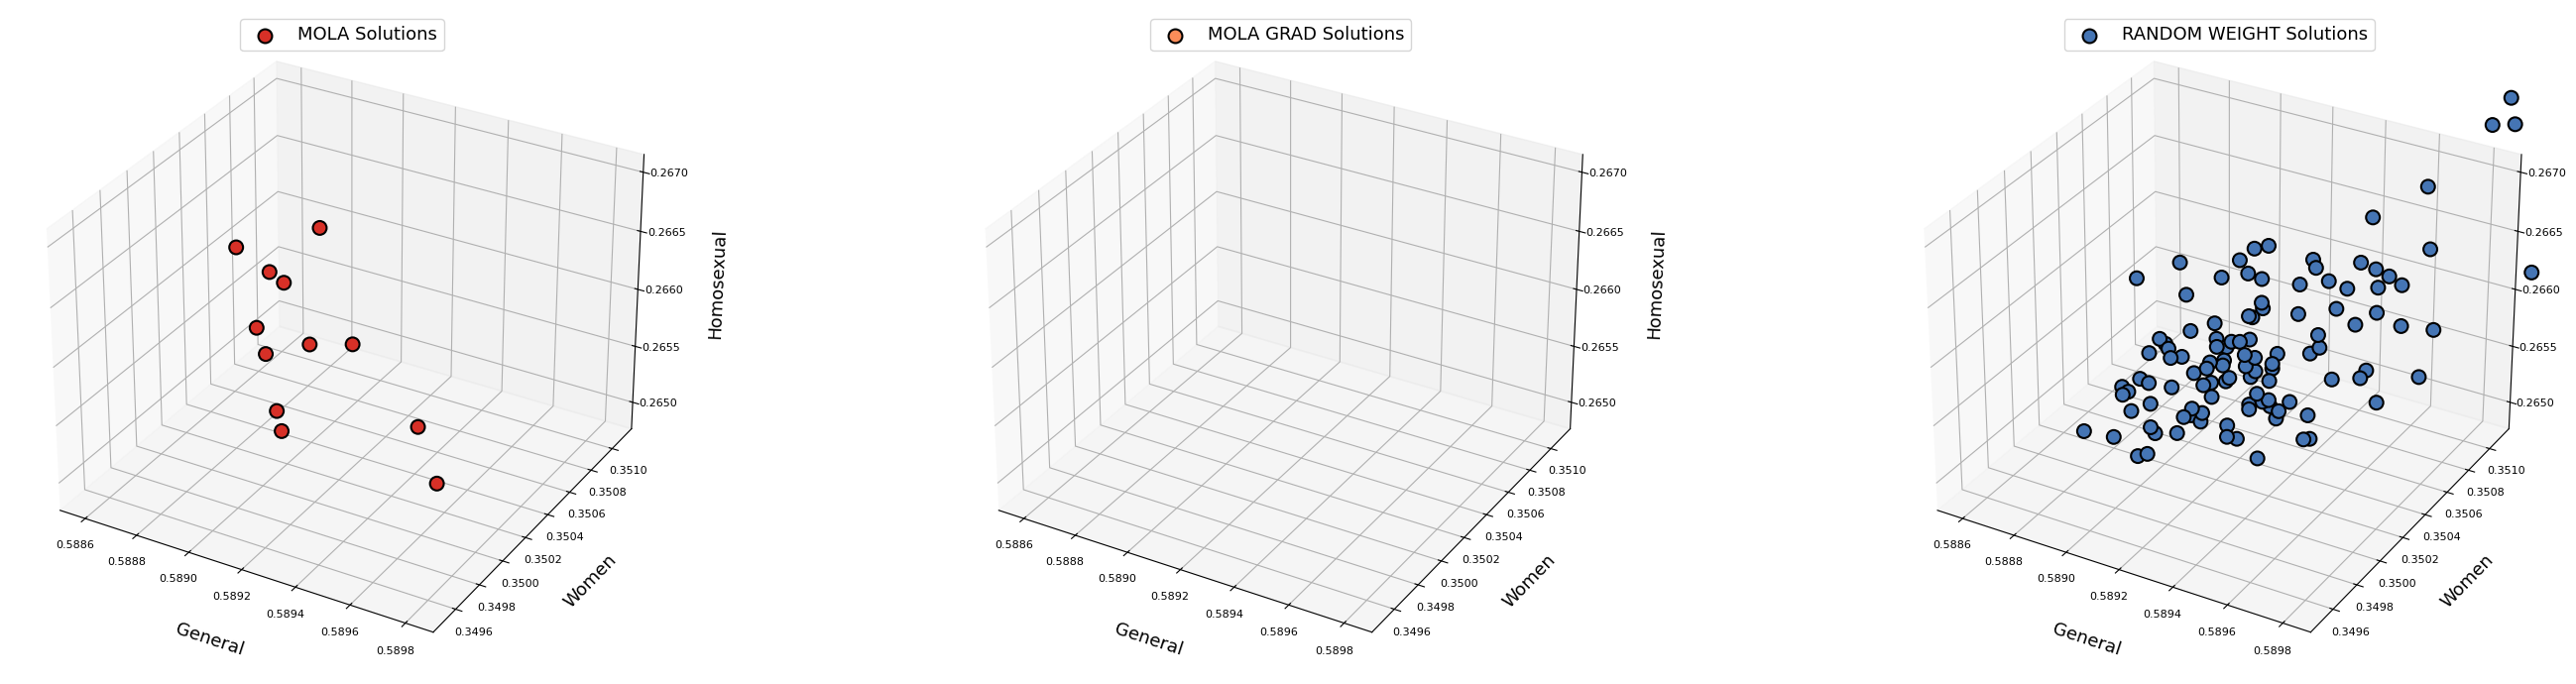

In [23]:
from machinemoo.analysis.visualization import plot_pareto_set_limit
plot_pareto_set_limit(methods=pareto_dict, axis_mode="global")
plot_pareto_set_limit(methods=pareto_dict, 
                      axis_mode="first", 
                      title="",
                      labels=task_names, 
                      fontsize=13,
                      figsize=(10,7),
                      save_path="images/3_objs_limit.pdf")

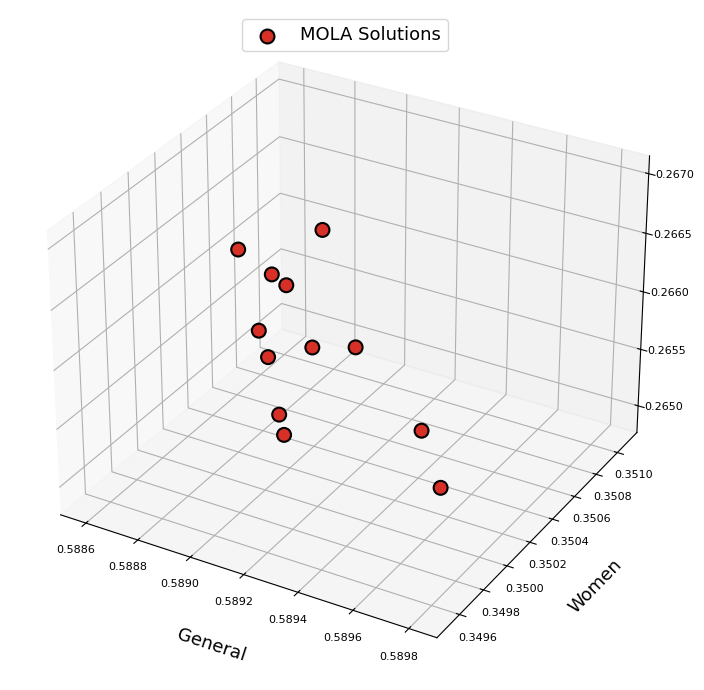

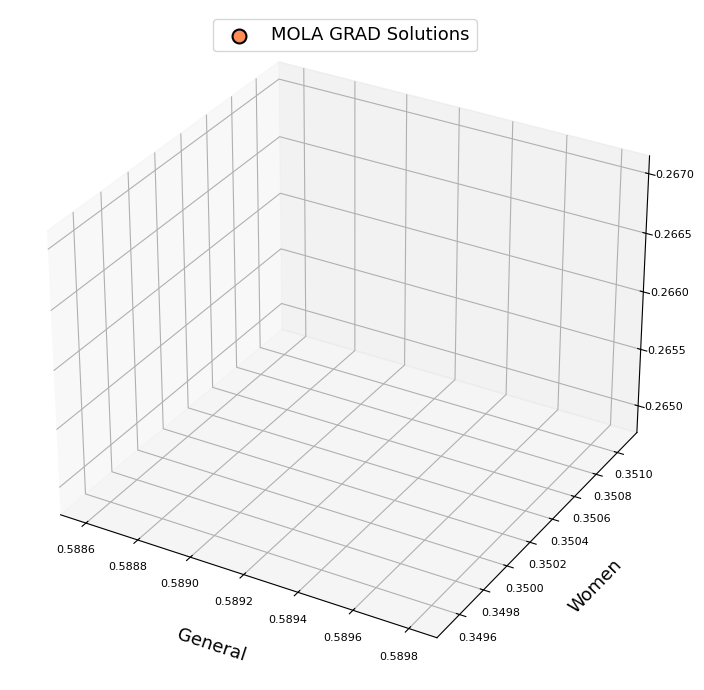

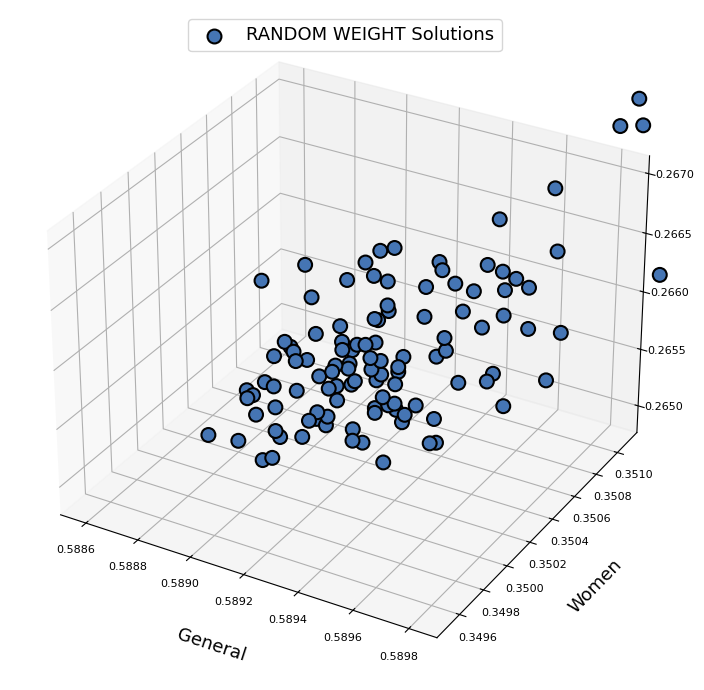

In [26]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

#for i in range(all_data.shape[1]):
#    limits.append(
#        (
#            all_data[:, i].min() - all_data[:, i].std(),
#            all_data[:, i].max() + all_data[:, i].std(),
#        )
#    )
first_objs = next(iter(pareto_dict.values()))
x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()
z_min, z_max = first_objs[:, 2].min() - first_objs[:, 2].std(), first_objs[:, 2].max() + first_objs[:, 2].std()

limits.append((x_min, x_max))
limits.append((y_min, y_max))
limits.append((z_min, z_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=task_names, 
                title=title,
                fontsize=13,
                figsize=(10,7),
                save_path=f'images/3_objs_{method}_limit.pdf',
                limits=limits
    )

In [27]:
def is_dominated(sol, others):
    return any(np.all(other <= sol) and np.any(other < sol) for other in others)

solutions = results['random_weight']['objectives']
non_dominated = []

for i, sol in enumerate(solutions):
    others = np.delete(solutions, i, axis=0)
    if not is_dominated(sol, others):
        non_dominated.append(sol)

non_dominated = np.array(non_dominated)
print(f"{len(non_dominated)} soluções não-dominadas encontradas.")


11 soluções não-dominadas encontradas.


In [28]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Supondo que `solutions` seja seu array (N x M)
solutions = results['random_weight']['objectives']

# Identifica os índices das soluções não-dominadas
nd_indices = NonDominatedSorting().do(solutions, only_non_dominated_front=True)

# Extrai as soluções não-dominadas
non_dominated_solutions = solutions[nd_indices]


print(f"mola: {len(results['mola']['objectives'])}")
print(f"mola_grad: {len(results['mola_grad']['objectives'])}")

print(f"Número de soluções não-dominadas (RW): {len(non_dominated_solutions)}")
print(non_dominated_solutions)

mola: 12
mola_grad: 24
Número de soluções não-dominadas (RW): 11
[[0.58887388 0.35048023 0.26548322]
 [0.58911671 0.35025038 0.26517111]
 [0.58906613 0.34984777 0.26521919]
 [0.58890996 0.34974983 0.26542029]
 [0.58892973 0.35023538 0.26521412]
 [0.5886426  0.35072943 0.26569618]
 [0.58908315 0.35024449 0.26520989]
 [0.58917032 0.34970787 0.26544789]
 [0.58905556 0.34968483 0.26553451]
 [0.58911938 0.34962945 0.26599029]
 [0.58908554 0.35074492 0.26508575]]


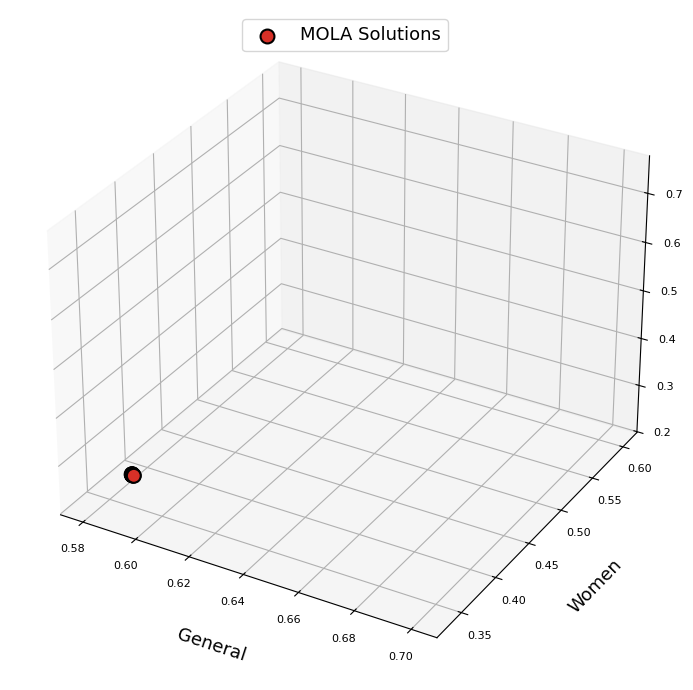

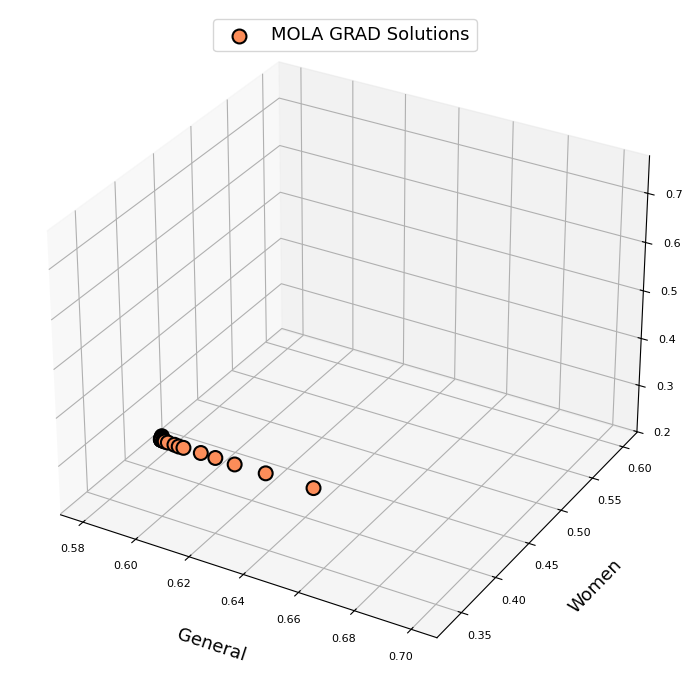

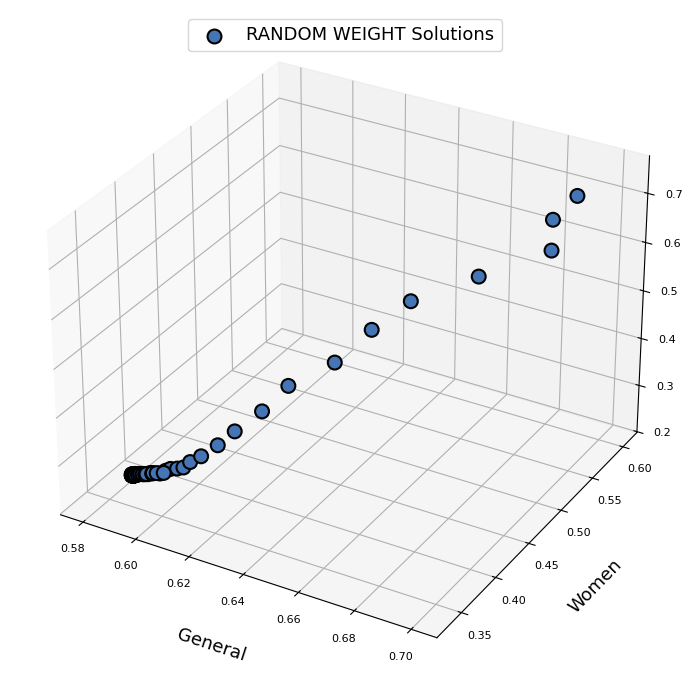

In [29]:
all_data = np.concatenate(list(pareto_dict.values()), axis=0)
limits = []
color: list[str] | str = ['#d73027', '#fc8d59', '#4575b4']

for i in range(all_data.shape[1]):
    limits.append(
        (
            all_data[:, i].min() - all_data[:, i].std(),
            all_data[:, i].max() + all_data[:, i].std(),
        )
    )
#first_objs = next(iter(pareto_dict.values()))
#x_min, x_max = first_objs[:, 0].min() - first_objs[:, 0].std(), first_objs[:, 0].max() + first_objs[:, 0].std()
#y_min, y_max = first_objs[:, 1].min() - first_objs[:, 1].std(), first_objs[:, 1].max() + first_objs[:, 1].std()
#z_min, z_max = first_objs[:, 2].min() - first_objs[:, 2].std(), first_objs[:, 2].max() + first_objs[:, 2].std()

#limits.append((x_min, x_max))
#limits.append((y_min, y_max))
#limits.append((z_min, z_max))

for i, (method, res) in enumerate(results.items()):
    plot_pareto(methods={method: res["objectives"]},
                color = color[i],
                labels=task_names, 
                title=title,
                fontsize=13,
                figsize=(10,7),
                save_path=f'images/3_objs_{method}_limit.pdf',
                limits=limits
    )